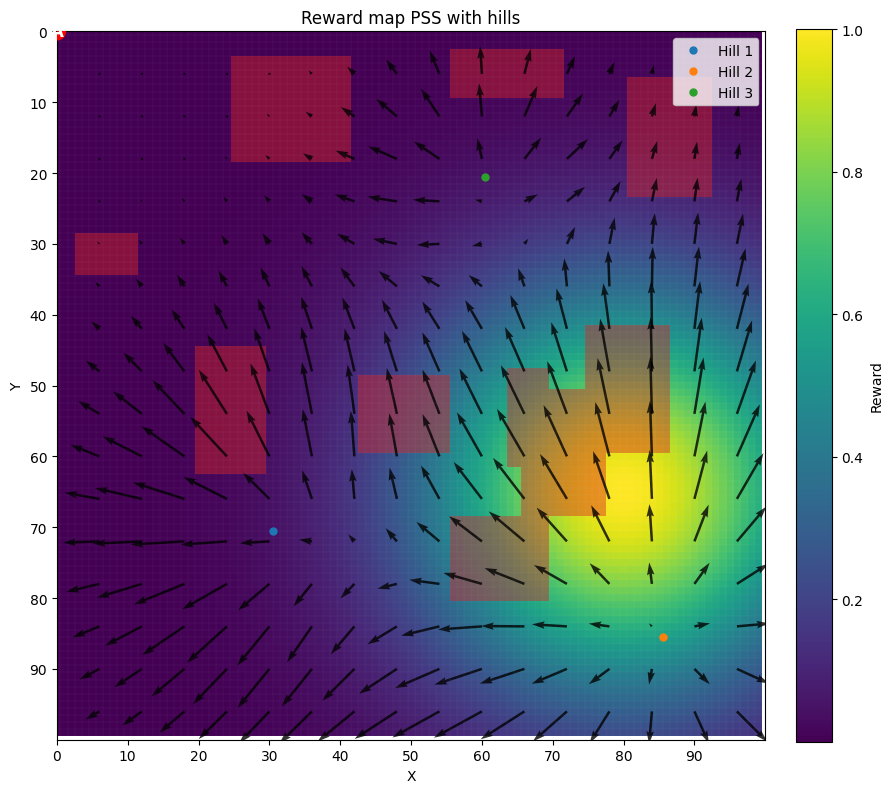

In [1]:
from pathlib import Path
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import sys
import numpy as np
from scipy.stats import multivariate_normal

start_state = (0, 0)

def plot_agent(location, ax=None, radius=1.2):
    x, y = location
    agent = Circle((x, y), radius=radius, color='red', zorder=3)
    ax.add_patch(agent)

    # Draw white 'A' in the center
    ax.text(
        x, y, 'A',
        color='white',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=4
    )


# Ensure project root (parent of notebooks/) is on PYTHONPATH
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import directly from module (not from src/__init__.py)
from src.environment_2 import ProbabilisticSimpleSystem

env = ProbabilisticSimpleSystem(seed=64)
env.clear_hills()
env.add_hill(top=(30, 70), sigma=15.0, strength=35, normalized=False)
env.add_hill(top=(85, 85), sigma=30.0, strength=100, normalized=False)
env.add_hill(top=(60, 20), sigma = 10, strength=15.0, normalized=False)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
env.plot_combined(ax=ax)
env.plot_hills(ax=ax)
ax.set_title("Reward map PSS with hills")
plot_agent(start_state, ax=ax)
plt.show()


states_visited = {start_state: 1}

In [ ]:
actions = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # right, up, left, down

# The \mathcal{P}(s' | s, a) function. A estimate of the real one, no hills
# Taken from the PSS code, but with hills removed
# Will later be replaced with the GP output
def est_trans_prop(state, action, env=env):
    step_size = env.step_size
    sigma_perpendicular = env.sigma_perpendicular
    sigma_parallel = env.sigma_parallel

    dx, dy = action
    x, y = state
    
    mean_x = x + step_size * dx
    mean_y = y + step_size * dy
    
    if dx != 0: 
        cov = np.array([
            [sigma_parallel**2, 0],
            [0, sigma_perpendicular**2]
        ])
    else:  
        cov = np.array([
            [sigma_perpendicular**2, 0],
            [0, sigma_parallel**2]
        ])

    return np.array([mean_x, mean_y]), cov

PROB_THRESHOLD = .02

def compute_transition_probs(state, action, window=10, env=env, threshold=PROB_THRESHOLD):
    """
    Returns arrays (coords, probs) of neighbor cells with P(s'|s,a) > threshold.
    coords: (N, 2) int array of (x', y') positions
    probs: (N,) array of normalized probabilities
    """
    mean, cov = est_trans_prop(state, action, env)
    grid_max = env.grid_shape[0] - 1


    # set a window around the mean to consider for probabilities
    # avoids 400M operations for the full grid
    x_min = max(0, int(np.floor(mean[0])) - window)
    x_max = min(grid_max, int(np.ceil(mean[0])) + window)
    y_min = max(0, int(np.floor(mean[1])) - window)
    y_max = min(grid_max, int(np.ceil(mean[1])) + window)

    xs = np.arange(x_min, x_max + 1)
    ys = np.arange(y_min, y_max + 1)
    xx, yy = np.meshgrid(xs, ys, indexing='ij')
    points = np.stack([xx.ravel(), yy.ravel()], axis=-1)

    rv = multivariate_normal(mean=mean, cov=cov)
    probs = rv.pdf(points)

    mask = probs > threshold
    coords = points[mask]
    probs = probs[mask]

    probs /= probs.sum()
    return coords.astype(int), probs

In [ ]:
max_x, max_y = env.grid_size
def value_iteration(env, gamma=0.99, theta=1e-4, max_iter=1000):
    V = np.zeros((max_x, max_y))
    for iteration in range(max_iter):
        delta = 0
        for x in range(max_x):
            for y in range(max_y):
                q_values = []
                for a_idx, action in enumerate(actions):


                    # compute Q(s,a) using truncated Gaussian


                    q_values.append(q_sa)
                    old_v = V[x, y]
                    V[x, y] = max(q_values)
                    delta = max(delta, abs(V[x, y] - old_v))
        if delta < theta:
            break
    return V

In [ ]:
max_x, max_y = env.grid_size
def policy_evaluation(env, policy, gamma=0.99, theta=1e-4):
    V = np.zeros((max_x, max_y))
    # iterate until convergence
    # V(s) = Σ_{s'} P(s'|s, π(s)) * [R(s') + γ*V(s')]
    return V

def policy_improvement(env, V, gamma=0.99):
    policy = np.zeros((max_x, max_y), dtype=int)
    stable = True
    for x in range(max_x):
        for y in range(max_y):

            q_values = [compute_q(env, (x,y), a, V, gamma) for a in actions]
            
            best = np.argmax(q_values)
            if best != policy[x, y]:
                stable = False
                policy[x, y] = best
    return policy, stable

def policy_iteration(env, gamma=0.99):
    policy = np.zeros((max_x, max_y), dtype=int) # start, always 'up'
    while True:
        V = policy_evaluation(env, policy, gamma)
        policy, stable = policy_improvement(env, V, gamma)
        if stable:
            break
    return policy, V